In [1]:
import pandas as pd
import numpy as np

# Define a opção para mostrar TODAS as colunas, sem limite
pd.set_option('display.max_columns', None)

# Define a opção para mostrar TODAS as linhas, sem limite
pd.set_option('display.max_rows', None)


# Define a opção para mostrar o número máximo de elementos do array como infinito (None)
np.set_printoptions(threshold=np.inf)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


Função para limpeza dos dados antes do experimento

retira colunas de estatísticas de primeira ordem e tambem retira o efeito da direção, filtrando em apenas uma direção

In [23]:
def pre_processing(df_original, direction):

    weakColumns   = ['B1_weak', 'B2_weak', 'B3_weak', 'B4_weak', 'B5_weak', 'B6_weak', 'B7_weak', 'B8_weak', 'B9_weak']
    strongColumns = ['B1_strong', 'B2_strong', 'B3_strong', 'B4_strong', 'B5_strong', 'B6_strong', 'B7_strong', 'B8_strong', 'B9_strong']
    avgColumns    = ['B1_avg', 'B2_avg', 'B3_avg', 'B4_avg', 'B5_avg', 'B6_avg', 'B7_avg',  'B8_avg', 'B9_avg']
    delColum      = ['Alpha', 'Beta', 'Gamma', 'Seno', 'Cosseno', 'Created', 'Brand', 'Model']

    df = df_original[df_original['Direction'] == direction]
    dropColumns = weakColumns + strongColumns + delColum

    df_processed = df.drop(dropColumns, axis=1)

    return df_processed

# Leave one out

construção dos dados de treinos

In [40]:
df = pd.read_csv("../dataset-completo.csv")
devices = df["Device"].unique()

LOO_List = [([devices[j] for j in range(len(devices)) if j != i], devices[i])\
              for i in range(len(devices))]



# Treinamento

In [41]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

data_path = "../dataset-completo.csv"
df_complete = pd.read_csv(data_path)

def loo_basic(i, loo_list, direcao):

    # ---------------------------- Seperação dos dados seguindo as regras do LOSO ----------------------------

    fold = loo_list[i]
    devices_train = fold[0]
    device_validation = fold[1]

    print(f"------------------------------------------ Experimento da validação em {device_validation} ------------------------------------------")
    
    df_pre_processed = pre_processing(df_complete, direcao)
    df_train = df_pre_processed[df_pre_processed["Device"]!=device_validation]
    df_test = df_pre_processed[df_pre_processed["Device"]==device_validation]

    # ---------------------------- Treinamento do modelo ----------------------------
    RP_TRAIN = df_train["RP"]
    SAMPLES_TRAIN = df_train.drop(['RP', 'X', 'Y', 'Direction', 'Device'], axis=1)

    X_train = SAMPLES_TRAIN
    Y_train = RP_TRAIN

    knn = KNeighborsClassifier(metric='euclidean', n_neighbors=1)
    knn.fit(X_train, Y_train)


    # ---------------------------- Predição com os dados de teste ----------------------------

    RP_TEST =  df_test['RP']
    SAMPLES_TEST = df_test.drop(['RP', 'X', 'Y', 'Direction', 'Device'], axis=1)

    X_test = SAMPLES_TEST
    Y_test = RP_TEST

    predictions = knn.predict(X_test)

    # ---------------------------- Métricas para análises ----------------------------

    accuracy = round(accuracy_score(Y_test, predictions), 2)
    recall = round(recall_score(Y_test, predictions, average='macro'), 2)
    f1 = round(f1_score(Y_test, predictions, average='macro'), 2)
    precision = round(precision_score(Y_test, predictions, average='macro'), 2)

    metrics = {
        'accuracy': accuracy,
        'recall': recall,
        'f1':f1,
        'precision':precision
    }

    return metrics

In [45]:
colunas = ["direction","device_validation","model", "metric", "result"]
df_result = pd.DataFrame(columns=colunas)

for fold in range(len(LOO_List)):
    
    list_fold = LOO_List[fold]
    device_validation = list_fold[1]

    results_metrics = loo_basic(fold, LOO_List, "norte")
    
    print(device_validation)
    for metric, result in results_metrics.items():
        new_row = {
            "direction": "norte",
            "device_validation":device_validation,
            "model":"KNN",
            "metric":metric,
            "result":result
        }
        df_result.loc[len(df_result)] = new_row

df_result.to_csv("../datasets/resultado_experimento_heterogeneidade.csv", index=False)
    


------------------------------------------ Experimento da validação em Luis3 ------------------------------------------
Luis3
------------------------------------------ Experimento da validação em Moto7 ------------------------------------------
Moto7
------------------------------------------ Experimento da validação em Wellington ------------------------------------------
Wellington
------------------------------------------ Experimento da validação em Chaparro ------------------------------------------
Chaparro
------------------------------------------ Experimento da validação em Moto01 ------------------------------------------
Moto01
------------------------------------------ Experimento da validação em Moto6 ------------------------------------------
Moto6
------------------------------------------ Experimento da validação em Moto8 ------------------------------------------
Moto8
------------------------------------------ Experimento da validação em Joao ------------------------

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Josue
------------------------------------------ Experimento da validação em JulieS ------------------------------------------
JulieS
------------------------------------------ Experimento da validação em Matteo ------------------------------------------
Matteo
------------------------------------------ Experimento da validação em Francisco ------------------------------------------
Francisco
------------------------------------------ Experimento da validação em Maggila ------------------------------------------
Maggila
------------------------------------------ Experimento da validação em FelipeAmaral ------------------------------------------
FelipeAmaral
------------------------------------------ Experimento da validação em Yuri ------------------------------------------
Yuri
------------------------------------------ Experimento da validação em Moto2 ------------------------------------------
Moto2
------------------------------------------ Experimento da validação em Bruna -------

['Moto7']
[0.41 0.41 0.39 0.42]
['Moto6']
[0.42 0.42 0.4  0.43]
['Moto8']
[0.4  0.32 0.32 0.37]
['Moto2']
[0.41 0.41 0.39 0.4 ]


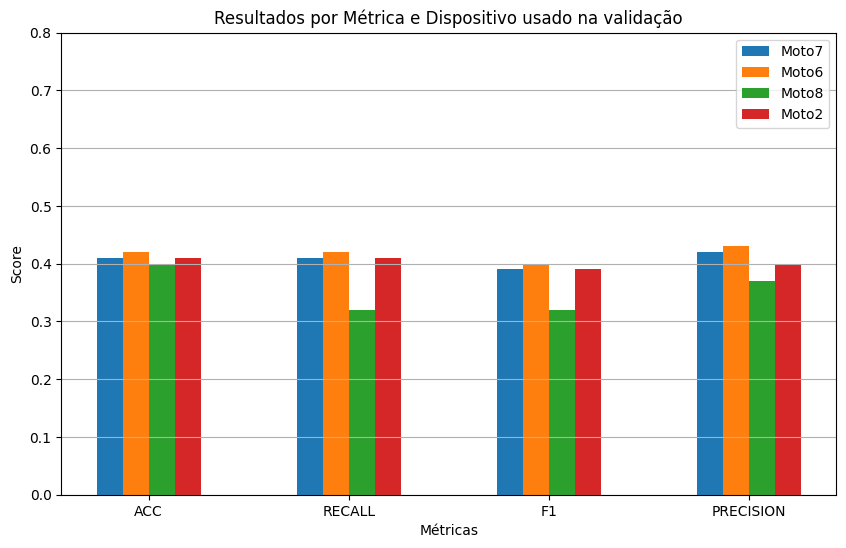

In [48]:
import matplotlib.pyplot as plt

df_results = pd.read_csv("../datasets/resultado_experimento_heterogeneidade.csv")

metricas = ['acc', 'recall', 'F1', 'precision']
devices = ["Moto7", "Moto6", "Moto8", "Moto2"]

x = np.arange(len(metricas))  # posições das métricas no eixo X
largura = 0.13  # largura das barras

plt.figure(figsize=(10, 6))

for i, device in enumerate(devices):
    df_device = df_results[df_results["device_validation"]==device]
    print(df_device["device_validation"].unique())
    y = df_device["result"].to_numpy()
    print(y)
    plt.bar(x + i*largura, y, width=largura, label=f"{device}")

plt.xlabel("Métricas")
plt.ylabel("Score")
plt.title("Resultados por Métrica e Dispositivo usado na validação")
plt.xticks(x + largura*(len(devices)-1)/2, [m.upper() for m in metricas])
plt.legend(loc='upper right')
plt.ylim(0, 0.8)
plt.grid(axis='y')

plt.show()